# functions

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import random
import time
import importlib
'''import importlib, racetrack1
importlib.reload(racetrack1)'''
import racetrack2 as racetrack

# =============================================================================
# HYPERPARAMETERS
# =============================================================================
EPSILON      = 0.1
ALPHA        = 0.5
GAMMA        = 1.0
MAX_EPISODES = 20000
MAX_STEPS    = 1000
EVAL_EVERY   = 50
SEED         = 0

In [6]:
def evaluate_greedy(track, starts, actions, Q, max_steps=5000, loop_threshold=10):
    """Run one deterministic greedy episode. Returns (steps, status)."""
    start_pos = starts[0]
    env_state = racetrack.reset_env(None, start_pos=start_pos)
    done  = False
    steps = 0

    sa_visit_count = defaultdict(int)

    while not done and steps < max_steps:
        agent_state = racetrack.get_agent_state(env_state)
        best_a_idx  = racetrack.greedy_action_index(Q, agent_state)
        best_a      = tuple(actions[best_a_idx])

        sa_visit_count[(agent_state, best_a_idx)] += 1
        if sa_visit_count[(agent_state, best_a_idx)] > loop_threshold:
            return steps, "looped"

        env_state, _, done = racetrack.step_env(track, env_state, best_a)
        steps += 1

    return (steps, "finished") if done else (steps, "timeout")

In [7]:
def train_sarsa(track, starts, actions, max_episodes=MAX_EPISODES,
                alpha=ALPHA, epsilon=EPSILON, gamma=GAMMA, seed=SEED):
    random.seed(seed)
    rng = np.random.default_rng(seed)

    Q = racetrack.create_q_table(track, init_value=0.0)

    path_lengths    = []
    eval_status_log = []
    ep_returns      = []
    start_time      = time.time()

    for ep in tqdm(range(1, max_episodes + 1), desc="SARSA"):
        env_state   = racetrack.reset_env(starts, start_index=ep)
        agent_state = racetrack.get_agent_state(env_state)
        action_idx  = racetrack.get_action_index(Q, agent_state, epsilon, rng)
        action      = tuple(actions[action_idx])

        done       = False
        step_count = 0
        ep_return  = 0.0

        while not done and step_count < MAX_STEPS:
            next_env_state, reward, done = racetrack.step_env(track, env_state, action)
            ep_return += reward
            y, x, vy, vx = agent_state

            if done:
                Q[y, x, vy, vx, action_idx] += alpha * (reward - Q[y, x, vy, vx, action_idx])
            else:
                next_agent_state = racetrack.get_agent_state(next_env_state)
                next_action_idx  = racetrack.get_action_index(Q, next_agent_state, epsilon, rng)
                ny, nx, nvy, nvx = next_agent_state

                td_target = reward + gamma * Q[ny, nx, nvy, nvx, next_action_idx]
                Q[y, x, vy, vx, action_idx] += alpha * (td_target - Q[y, x, vy, vx, action_idx])

                env_state   = next_env_state
                agent_state = next_agent_state
                action_idx  = next_action_idx
                action      = tuple(actions[action_idx])

            step_count += 1

        ep_returns.append(ep_return)

        if ep % EVAL_EVERY == 0:
            steps, status = evaluate_greedy(track, starts, actions, Q)
            eval_status_log.append((ep, steps, status))
            if status == "finished":
                path_lengths.append((ep, steps))

    train_time = time.time() - start_time
    return Q, path_lengths, eval_status_log, ep_returns, train_time

In [8]:
def train_q_learning(track, starts, actions, max_episodes=MAX_EPISODES,
                     alpha=ALPHA, epsilon=EPSILON, gamma=GAMMA, seed=SEED):
    random.seed(seed)
    rng = np.random.default_rng(seed)

    Q = racetrack.create_q_table(track, init_value=0.0)

    path_lengths    = []
    eval_status_log = []
    ep_returns      = []
    start_time      = time.time()

    for ep in tqdm(range(1, max_episodes + 1), desc="Q-Learning"):
        env_state   = racetrack.reset_env(starts, start_index=ep)
        agent_state = racetrack.get_agent_state(env_state)

        done       = False
        step_count = 0
        ep_return  = 0.0

        while not done and step_count < MAX_STEPS:
            action_idx = racetrack.get_action_index(Q, agent_state, epsilon, rng)
            action     = tuple(actions[action_idx])

            next_env_state, reward, done = racetrack.step_env(track, env_state, action)
            ep_return += reward
            y, x, vy, vx = agent_state

            if done:
                Q[y, x, vy, vx, action_idx] += alpha * (reward - Q[y, x, vy, vx, action_idx])
            else:
                next_agent_state = racetrack.get_agent_state(next_env_state)
                ny, nx, nvy, nvx = next_agent_state

                max_next_q = np.max(Q[ny, nx, nvy, nvx])
                td_target  = reward + gamma * max_next_q
                Q[y, x, vy, vx, action_idx] += alpha * (td_target - Q[y, x, vy, vx, action_idx])

                env_state   = next_env_state
                agent_state = next_agent_state

            step_count += 1

        ep_returns.append(ep_return)

        if ep % EVAL_EVERY == 0:
            steps, status = evaluate_greedy(track, starts, actions, Q)
            eval_status_log.append((ep, steps, status))
            if status == "finished":
                path_lengths.append((ep, steps))

    train_time = time.time() - start_time
    return Q, path_lengths, eval_status_log, ep_returns, train_time

In [9]:
def run_all_difficulties_sarsa(max_episodes=MAX_EPISODES):
    track_names = ["simple", "medium", "complex"]
    results     = {}

    for name in track_names:
        print(f"\n{'='*60}")
        print(f"  TRACK: {name.upper()}  |  SARSA")
        print(f"{'='*60}")

        track, starts, actions = racetrack.get_track(name)
        n_drivable = int(np.sum(track > 0))
        print(f"  Grid: {track.shape} | Drivable cells: {n_drivable} | Starts: {len(starts)}")
        print(f"  Training SARSA ({max_episodes:,} episodes)...")

        Q, path_lengths, eval_status_log, ep_returns, train_time = train_sarsa(
            track, starts, actions, max_episodes=max_episodes, seed=SEED)

        first_finish = path_lengths[0][0]  if path_lengths else None
        final_path   = path_lengths[-1][1] if path_lengths else None
        late_return  = float(np.mean(ep_returns[-100:]))

        print(f"  first finish ep {first_finish} | final path = {final_path} | "
              f"late return = {late_return:.1f} | time = {train_time:.1f}s")

        results[name] = {
            "track": track, "starts": starts, "actions": actions,
            "Q": Q,
            "pl": path_lengths,
            "log": eval_status_log,
            "ret": ep_returns,
            "late_ret": late_return,
            "train_time": train_time,
        }

    return results

In [10]:
def run_all_difficulties_qlearning(max_episodes=MAX_EPISODES):
    track_names = ["simple", "medium", "complex"]
    results     = {}

    for name in track_names:
        print(f"\n{'='*60}")
        print(f"  TRACK: {name.upper()}  |  Q-LEARNING")
        print(f"{'='*60}")

        track, starts, actions = racetrack.get_track(name)
        n_drivable = int(np.sum(track > 0))
        print(f"  Grid: {track.shape} | Drivable cells: {n_drivable} | Starts: {len(starts)}")
        print(f"  Training Q-Learning ({max_episodes:,} episodes)...")

        Q, path_lengths, eval_status_log, ep_returns, train_time = train_q_learning(
            track, starts, actions, max_episodes=max_episodes, seed=SEED)

        first_finish = path_lengths[0][0]  if path_lengths else None
        final_path   = path_lengths[-1][1] if path_lengths else None
        late_return  = float(np.mean(ep_returns[-100:]))

        print(f"  first finish ep {first_finish} | final path = {final_path} | "
              f"late return = {late_return:.1f} | time = {train_time:.1f}s")

        results[name] = {
            "track": track, "starts": starts, "actions": actions,
            "Q": Q,
            "pl": path_lengths,
            "log": eval_status_log,
            "ret": ep_returns,
            "late_ret": late_return,
            "train_time": train_time,
        }

    return results

In [11]:
# =============================================================================
# PLOTTING
# =============================================================================

C_SARSA = "#E74C3C"
C_QL    = "#2980B9"

def smooth(x, window=50):
    if len(x) < window:
        return np.array(x, dtype=float)
    return np.convolve(np.array(x, dtype=float), np.ones(window)/window, mode='valid')


def _to_xy(pairs):
    if not pairs:
        return [], []
    return [int(p[0]) for p in pairs], [int(p[1]) for p in pairs]


def plot_results(results_sarsa, results_ql):
    track_names = list(results_sarsa.keys())
    n_tracks    = len(track_names)

    # --- Figure 1: Online return ---
    fig, axes = plt.subplots(1, n_tracks, figsize=(18, 5))
    fig.suptitle("Online Episode Return During Training (smoothed, window=50)",
                 fontsize=13, fontweight='bold')
    for i, name in enumerate(track_names):
        ax        = axes[i]
        s_smooth  = smooth(results_sarsa[name]["ret"], 50)
        ql_smooth = smooth(results_ql[name]["ret"],    50)
        x_s  = np.arange(50, 50 + len(s_smooth))
        x_ql = np.arange(50, 50 + len(ql_smooth))
        ax.plot(x_s,  s_smooth,  color=C_SARSA, linewidth=2, label="SARSA")
        ax.plot(x_ql, ql_smooth, color=C_QL,    linewidth=2, label="Q-Learning")
        ax.set_title(f"{name.capitalize()} Track", fontsize=12, fontweight='bold')
        ax.set_xlabel("Episode"); ax.set_ylabel("Return")
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("td_online_return.png", dpi=120, bbox_inches='tight')
    plt.show()

    # --- Figure 2: Greedy path length over training ---
    fig, axes = plt.subplots(1, n_tracks, figsize=(18, 5))
    fig.suptitle("Greedy Policy Path Length (only successful evaluations shown)",
                 fontsize=13, fontweight='bold')
    for i, name in enumerate(track_names):
        ax = axes[i]
        eps_s, lens_s = _to_xy(results_sarsa[name]["pl"])
        if eps_s:
            ax.plot(eps_s, lens_s, color=C_SARSA, linewidth=2,
                    marker='o', markersize=3, label=f"SARSA (n={len(eps_s)})")
        eps_q, lens_q = _to_xy(results_ql[name]["pl"])
        if eps_q:
            ax.plot(eps_q, lens_q, color=C_QL, linewidth=2,
                    marker='s', markersize=3, label=f"Q-Learning (n={len(eps_q)})")
        ax.set_title(f"{name.capitalize()} Track", fontsize=12, fontweight='bold')
        ax.set_xlabel("Episode"); ax.set_ylabel("Greedy Path Length")
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("td_learning_curves.png", dpi=120, bbox_inches='tight')
    plt.show()

    # --- Figure 3: Trajectories ---
    fig, axes = plt.subplots(n_tracks, 2, figsize=(12, 6 * n_tracks))
    fig.suptitle("Final Greedy Policy Trajectories", fontsize=14, fontweight='bold')
    for i, name in enumerate(track_names):
        start_p = results_sarsa[name]["starts"][0]
        racetrack.plot_single_trajectory(
            results_sarsa[name]["track"], results_sarsa[name]["actions"],
            results_sarsa[name]["Q"],
            f"{name.capitalize()} — SARSA", start_p, C_SARSA, axes[i][0])
        racetrack.plot_single_trajectory(
            results_ql[name]["track"], results_ql[name]["actions"],
            results_ql[name]["Q"],
            f"{name.capitalize()} — Q-Learning", start_p, C_QL, axes[i][1])
    plt.tight_layout()
    plt.savefig("td_trajectories.png", dpi=120, bbox_inches='tight')
    plt.show()

    # --- Figure 4: Summary ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Summary: SARSA vs Q-Learning by Track Complexity",
                 fontsize=14, fontweight='bold')
    x      = np.arange(n_tracks)
    labels = [n.capitalize() for n in track_names]
    width  = 0.35

    # 1) Success rate
    ax = axes[0]
    sr_sarsa = [100.0 * sum(1 for _, _, s in results_sarsa[n]["log"] if s == "finished")
                / len(results_sarsa[n]["log"]) for n in track_names]
    sr_ql    = [100.0 * sum(1 for _, _, s in results_ql[n]["log"] if s == "finished")
                / len(results_ql[n]["log"]) for n in track_names]
    ax.bar(x - width/2, sr_sarsa, width, label="SARSA",      color=C_SARSA, alpha=0.85)
    ax.bar(x + width/2, sr_ql,    width, label="Q-Learning", color=C_QL,    alpha=0.85)
    ax.set_title("Greedy Evaluation Success Rate (%)", fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("% of checkpoints reaching goal"); ax.set_ylim(0, 105)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    # 2) Final greedy path length
    ax = axes[1]
    fp_sarsa = [int(results_sarsa[n]["pl"][-1][1]) if results_sarsa[n]["pl"] else 0
                for n in track_names]
    fp_ql    = [int(results_ql[n]["pl"][-1][1])    if results_ql[n]["pl"]    else 0
                for n in track_names]
    ax.bar(x - width/2, fp_sarsa, width, label="SARSA",      color=C_SARSA, alpha=0.85)
    ax.bar(x + width/2, fp_ql,    width, label="Q-Learning", color=C_QL,    alpha=0.85)
    ax.set_title("Final Greedy Path Length\n(0 = never finished)", fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("Steps"); ax.legend(); ax.grid(axis='y', alpha=0.3)

    # 3) Late online return
    ax = axes[2]
    lr_sarsa = [results_sarsa[n]["late_ret"] for n in track_names]
    lr_ql    = [results_ql[n]["late_ret"]    for n in track_names]
    ax.bar(x - width/2, lr_sarsa, width, label="SARSA",      color=C_SARSA, alpha=0.85)
    ax.bar(x + width/2, lr_ql,    width, label="Q-Learning", color=C_QL,    alpha=0.85)
    ax.set_title("Mean Online Return (last 100 eps)", fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("Return"); ax.legend(); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig("td_summary.png", dpi=120, bbox_inches='tight')
    plt.show()

In [37]:
def print_evaluation_summary(results_sarsa, results_ql,
                              max_episodes_sarsa=MAX_EPISODES,
                              max_episodes_ql=MAX_EPISODES):
    print("\n" + "=" * 80)
    print("GREEDY EVALUATION STATUS SUMMARY")
    print(f"(SARSA: {max_episodes_sarsa // EVAL_EVERY} checkpoints | "
          f"Q-Learning: {max_episodes_ql // EVAL_EVERY} checkpoints)")
    print("=" * 80)
    print(f"{'Track':<10} {'Algo':<12} {'finished':>10} {'looped':>8} {'timeout':>8} {'%fin':>8} {'avg_steps':>10}")
    print("-" * 80)
    for name in ["simple", "medium", "complex"]:
        for label, res in [("SARSA", results_sarsa), ("Q-Learning", results_ql)]:
            log        = res[name]["log"]
            fin_logs   = [(ep, steps, s) for ep, steps, s in log if s == "finished"]
            n_fin      = len(fin_logs)
            n_loop     = sum(1 for _, _, s in log if s == "looped")
            n_tout     = sum(1 for _, _, s in log if s == "timeout")
            pct        = 100.0 * n_fin / len(log) if log else 0.0
            avg_steps  = sum(steps for _, steps, _ in fin_logs) / n_fin if n_fin else float("nan")
            print(f"{name:<10} {label:<12} {n_fin:>10} {n_loop:>8} {n_tout:>8} "
                  f"{pct:>8.1f}% {avg_steps:>10.1f}")

# models


Starting TD experiment: SARSA vs Q-Learning
Episodes: 40,000 40,000 | ε=0.1 | α=0.5 | γ=1.0 | seed=0

  TRACK: SIMPLE  |  SARSA
  Grid: (34, 18) | Drivable cells: 289 | Starts: 3
  Training SARSA (40,000 episodes)...


SARSA:   0%|          | 0/40000 [00:00<?, ?it/s]

SARSA: 100%|██████████| 40000/40000 [00:29<00:00, 1376.70it/s]


  first finish ep 350 | final path = 13 | late return = -15.2 | time = 29.1s

  TRACK: MEDIUM  |  SARSA
  Grid: (46, 26) | Drivable cells: 199 | Starts: 3
  Training SARSA (40,000 episodes)...


SARSA: 100%|██████████| 40000/40000 [00:53<00:00, 754.51it/s] 


...

  first finish ep 50 | final path = 10 | late return = -12.3 | time = 28.3s

  TRACK: MEDIUM  |  Q-LEARNING
  Grid: (46, 26) | Drivable cells: 199 | Starts: 3
  Training Q-Learning (40,000 episodes)...


Q-Learning: 100%|██████████| 40000/40000 [00:43<00:00, 928.45it/s] 


  first finish ep 150 | final path = 16 | late return = -24.1 | time = 43.1s

  TRACK: COMPLEX  |  Q-LEARNING
  Grid: (52, 38) | Drivable cells: 515 | Starts: 3
  Training Q-Learning (40,000 episodes)...


Q-Learning: 100%|██████████| 40000/40000 [01:47<00:00, 373.33it/s]


  first finish ep 900 | final path = 25 | late return = -44.6 | time = 107.1s

GREEDY EVALUATION STATUS SUMMARY
(SARSA: 800 checkpoints | Q-Learning: 800 checkpoints)
Track      Algo           finished   looped  timeout
------------------------------------------------------------
simple     SARSA               721       79        0     90.1%
simple     Q-Learning          752       48        0     94.0%
medium     SARSA               687      113        0     85.9%
medium     Q-Learning          753       47        0     94.1%
complex    SARSA               522      278        0     65.2%
complex    Q-Learning          714       86        0     89.2%


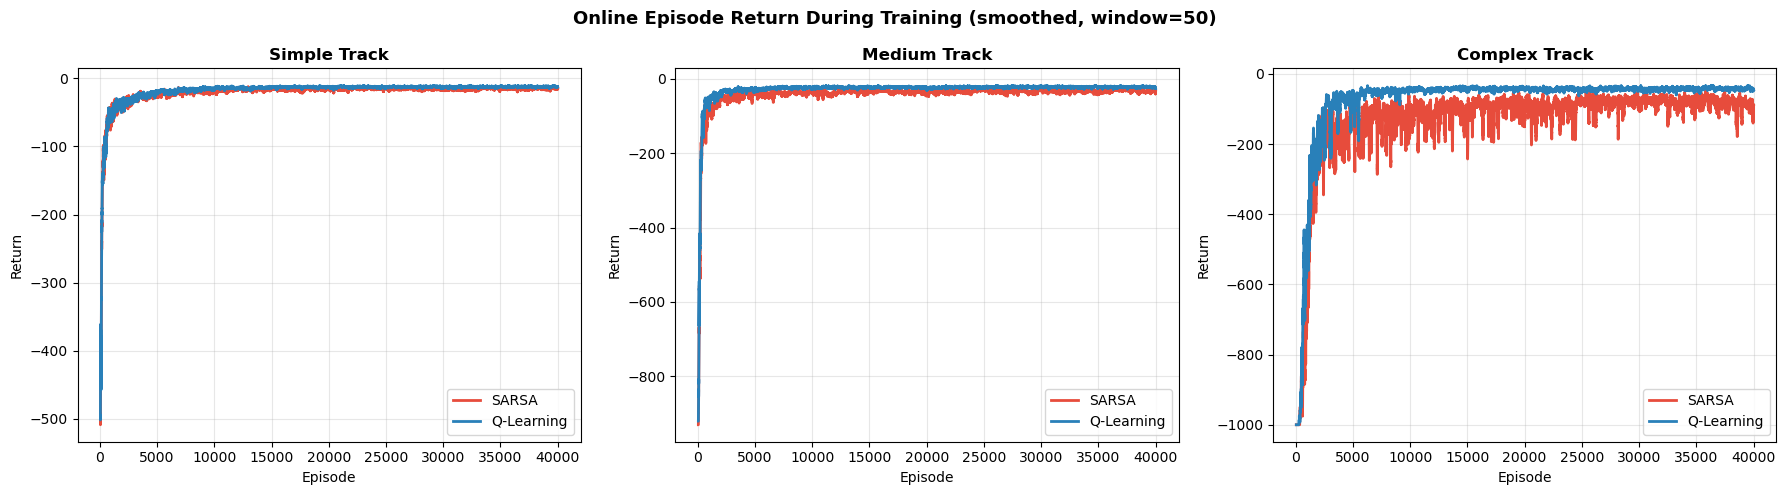

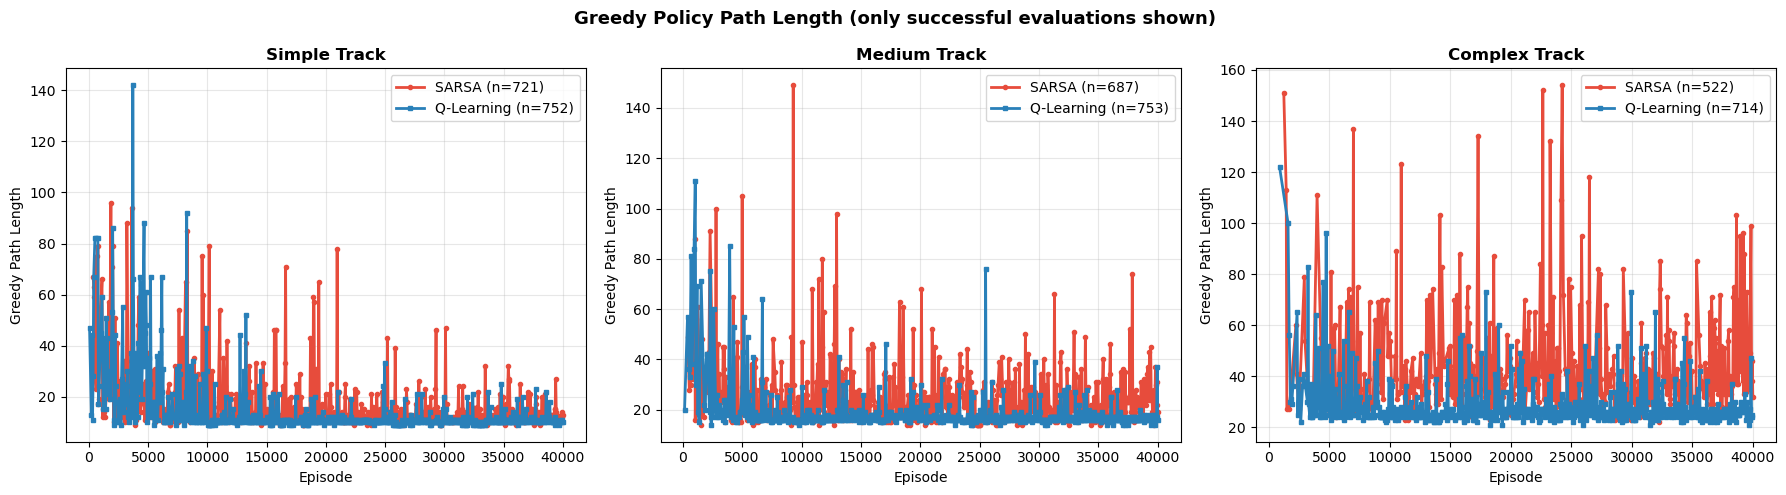

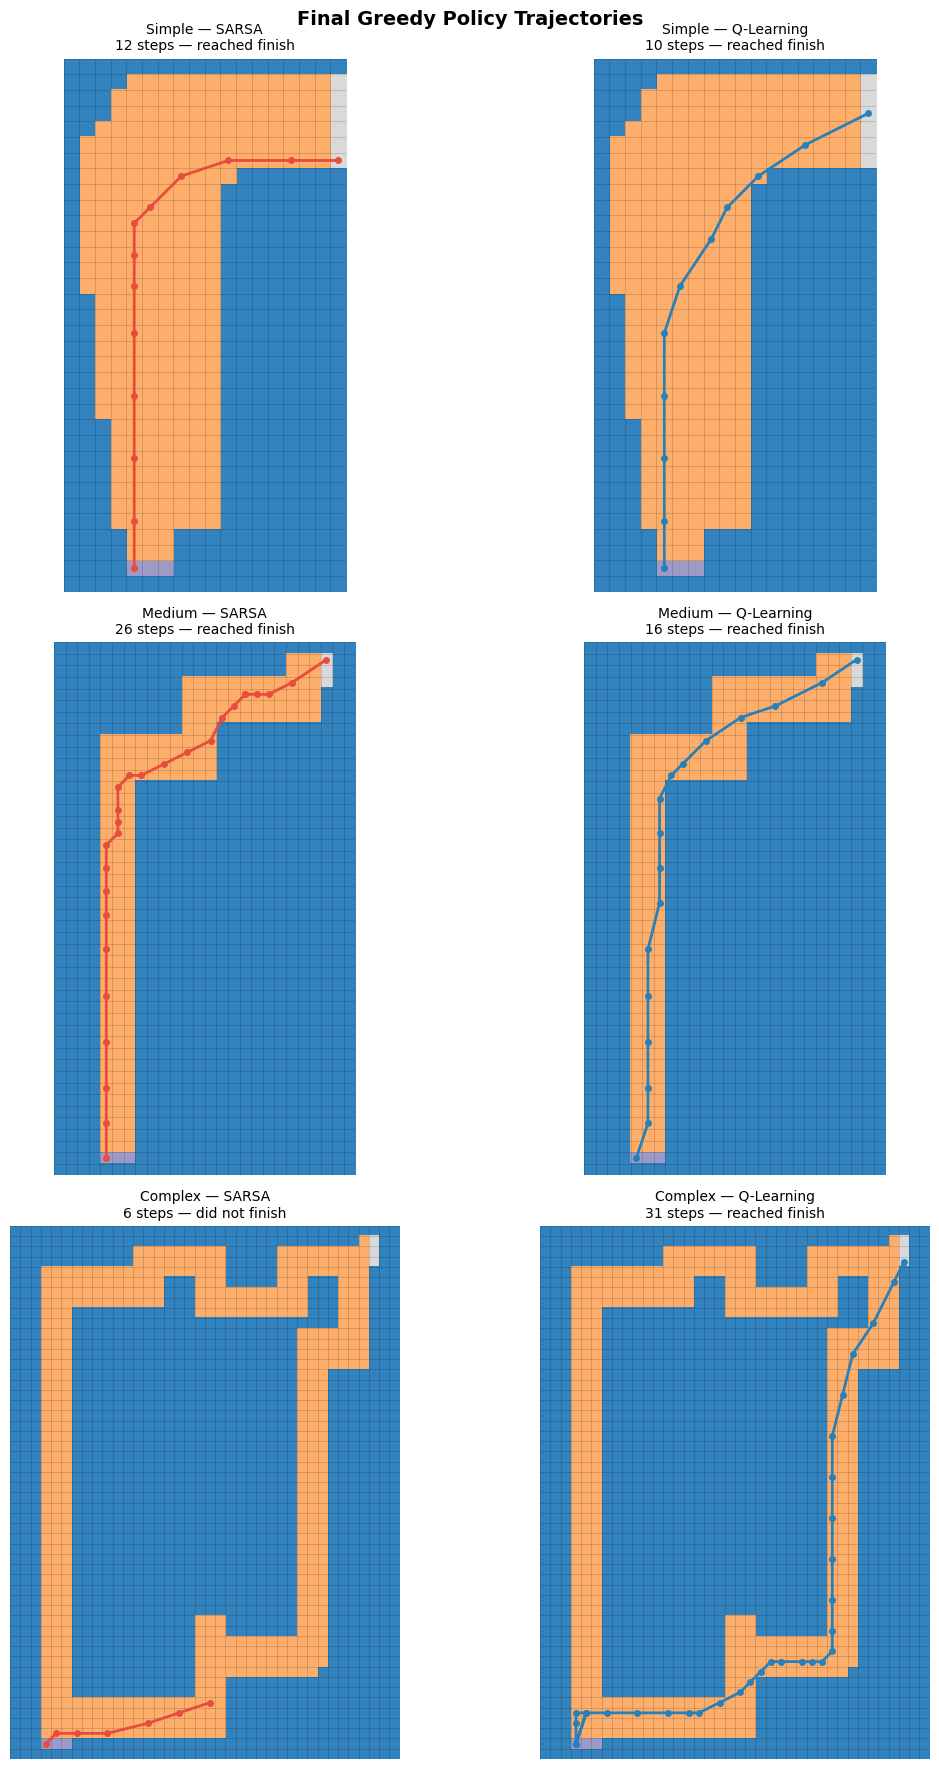

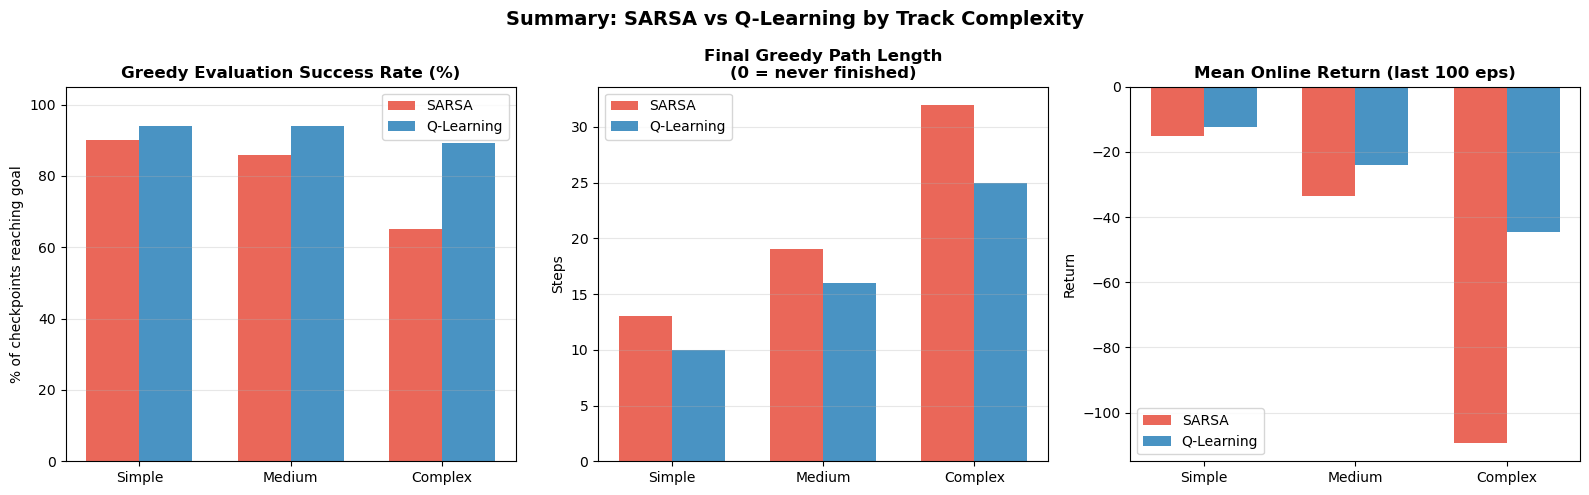


=== EXPERIMENT COMPLETE ===
Saved figures: td_online_return.png, td_learning_curves.png, td_trajectories.png, td_summary.png


In [13]:
# =============================================================================
# EXECUTION  —  change MAX_EPISODES here to rerun with a different budget
# =============================================================================
MAX_EPISODES_S = 40000
MAX_EPISODES_Q = 40000

print("Starting TD experiment: SARSA vs Q-Learning")
print(f"Episodes: {MAX_EPISODES_S:,} {MAX_EPISODES_Q:,} | ε={EPSILON} | α={ALPHA} | γ={GAMMA} | seed={SEED}")

results_sarsa = run_all_difficulties_sarsa(max_episodes=MAX_EPISODES_S)
results_ql    = run_all_difficulties_qlearning(max_episodes=MAX_EPISODES_Q)

print_evaluation_summary(results_sarsa, results_ql,
                          max_episodes_sarsa=MAX_EPISODES_S,
                          max_episodes_ql=MAX_EPISODES_Q)
plot_results(results_sarsa, results_ql)

print("\n=== EXPERIMENT COMPLETE ===")
print("Saved figures: td_online_return.png, td_learning_curves.png, "
      "td_trajectories.png, td_summary.png")

Starting TD experiment: SARSA vs Q-Learning
Episodes: 20,000 20,000 | ε=0.1 | α=0.5 | γ=1.0 | seed=0

  TRACK: SIMPLE  |  SARSA
  Grid: (34, 18) | Drivable cells: 289 | Starts: 3
  Training SARSA (20,000 episodes)...


SARSA: 100%|██████████| 20000/20000 [00:17<00:00, 1118.52it/s]


  first finish ep 200 | final path = 12 | late return = -15.4 | time = 17.9s

  TRACK: MEDIUM  |  SARSA
  Grid: (46, 26) | Drivable cells: 199 | Starts: 3
  Training SARSA (20,000 episodes)...


SARSA: 100%|██████████| 20000/20000 [00:35<00:00, 563.31it/s]


  first finish ep 400 | final path = 22 | late return = -37.0 | time = 35.5s

  TRACK: COMPLEX  |  SARSA
  Grid: (52, 38) | Drivable cells: 515 | Starts: 3
  Training SARSA (20,000 episodes)...


...

  first finish ep 350 | final path = 10 | late return = -13.9 | time = 18.8s

  TRACK: MEDIUM  |  Q-LEARNING
  Grid: (46, 26) | Drivable cells: 199 | Starts: 3
  Training Q-Learning (20,000 episodes)...


Q-Learning: 100%|██████████| 20000/20000 [00:28<00:00, 713.96it/s] 


  first finish ep 100 | final path = 17 | late return = -26.0 | time = 28.0s

  TRACK: COMPLEX  |  Q-LEARNING
  Grid: (52, 38) | Drivable cells: 515 | Starts: 3
  Training Q-Learning (20,000 episodes)...


Q-Learning: 100%|██████████| 20000/20000 [01:16<00:00, 261.23it/s]


  first finish ep 800 | final path = 23 | late return = -43.1 | time = 76.6s

GREEDY EVALUATION STATUS SUMMARY
(SARSA: 400 checkpoints | Q-Learning: 400 checkpoints)
Track      Algo           finished   looped  timeout
------------------------------------------------------------
simple     SARSA               323       77        0     80.8%
simple     Q-Learning          360       40        0     90.0%
medium     SARSA               306       94        0     76.5%
medium     Q-Learning          349       51        0     87.2%
complex    SARSA               212      188        0     53.0%
complex    Q-Learning          331       69        0     82.8%


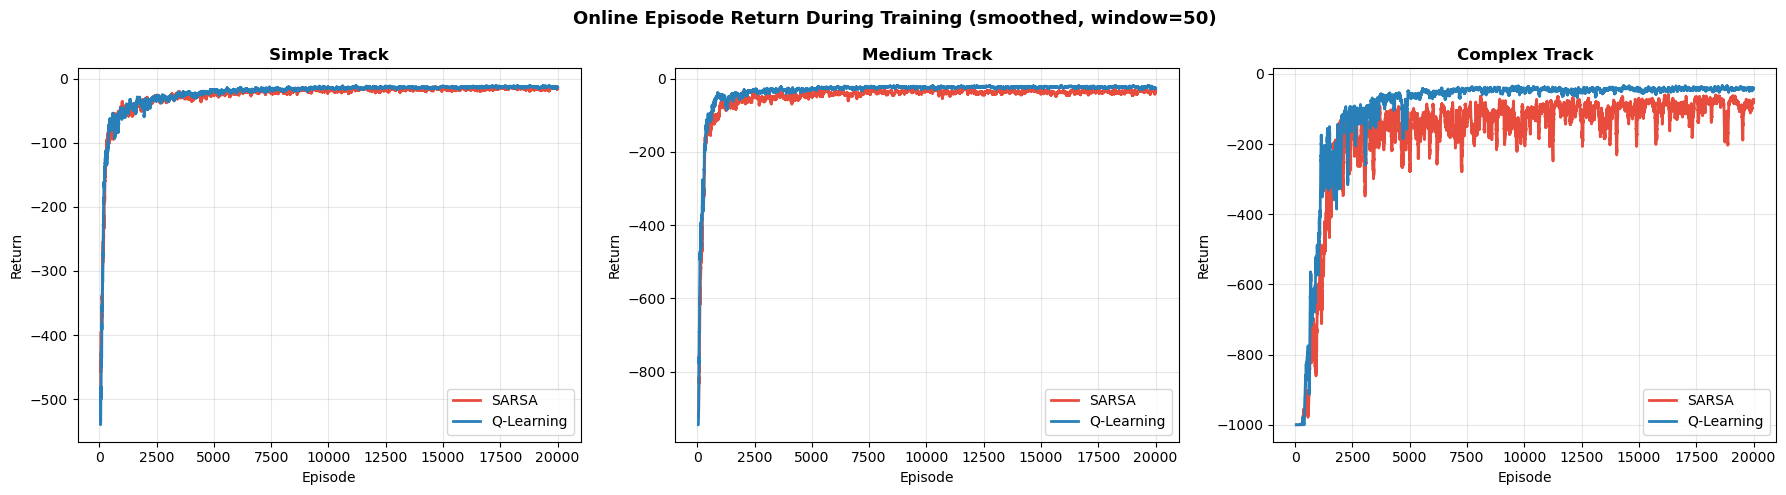

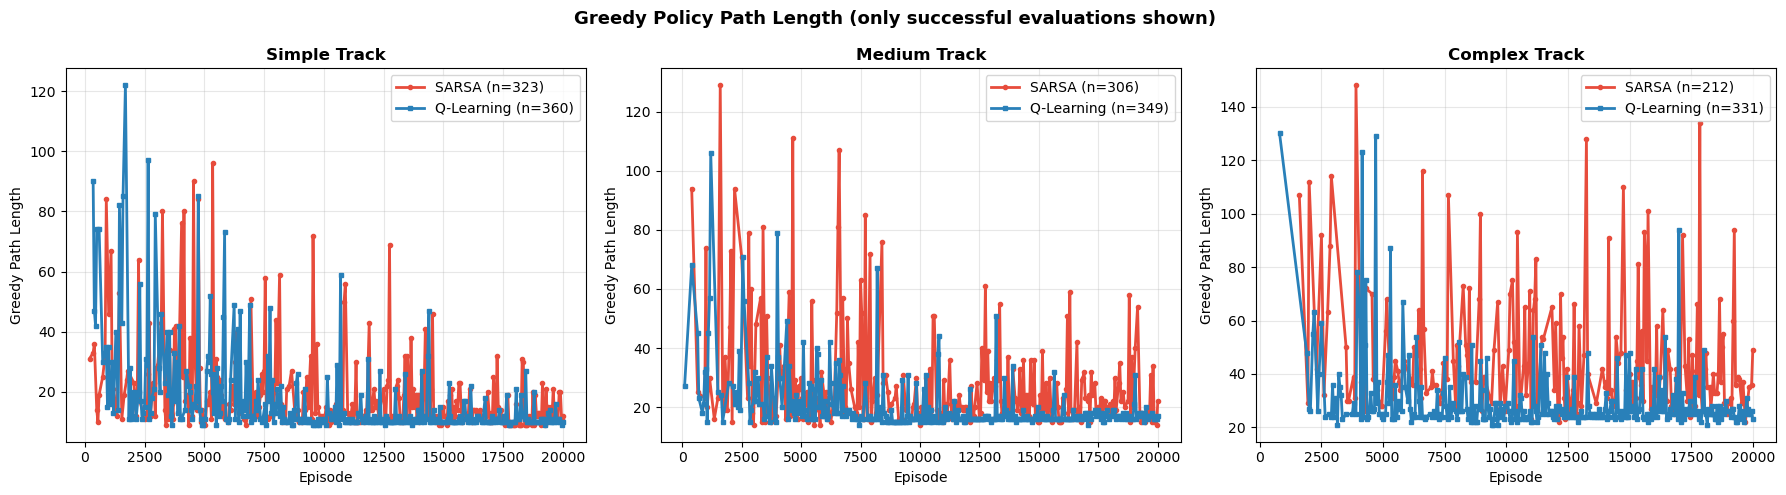

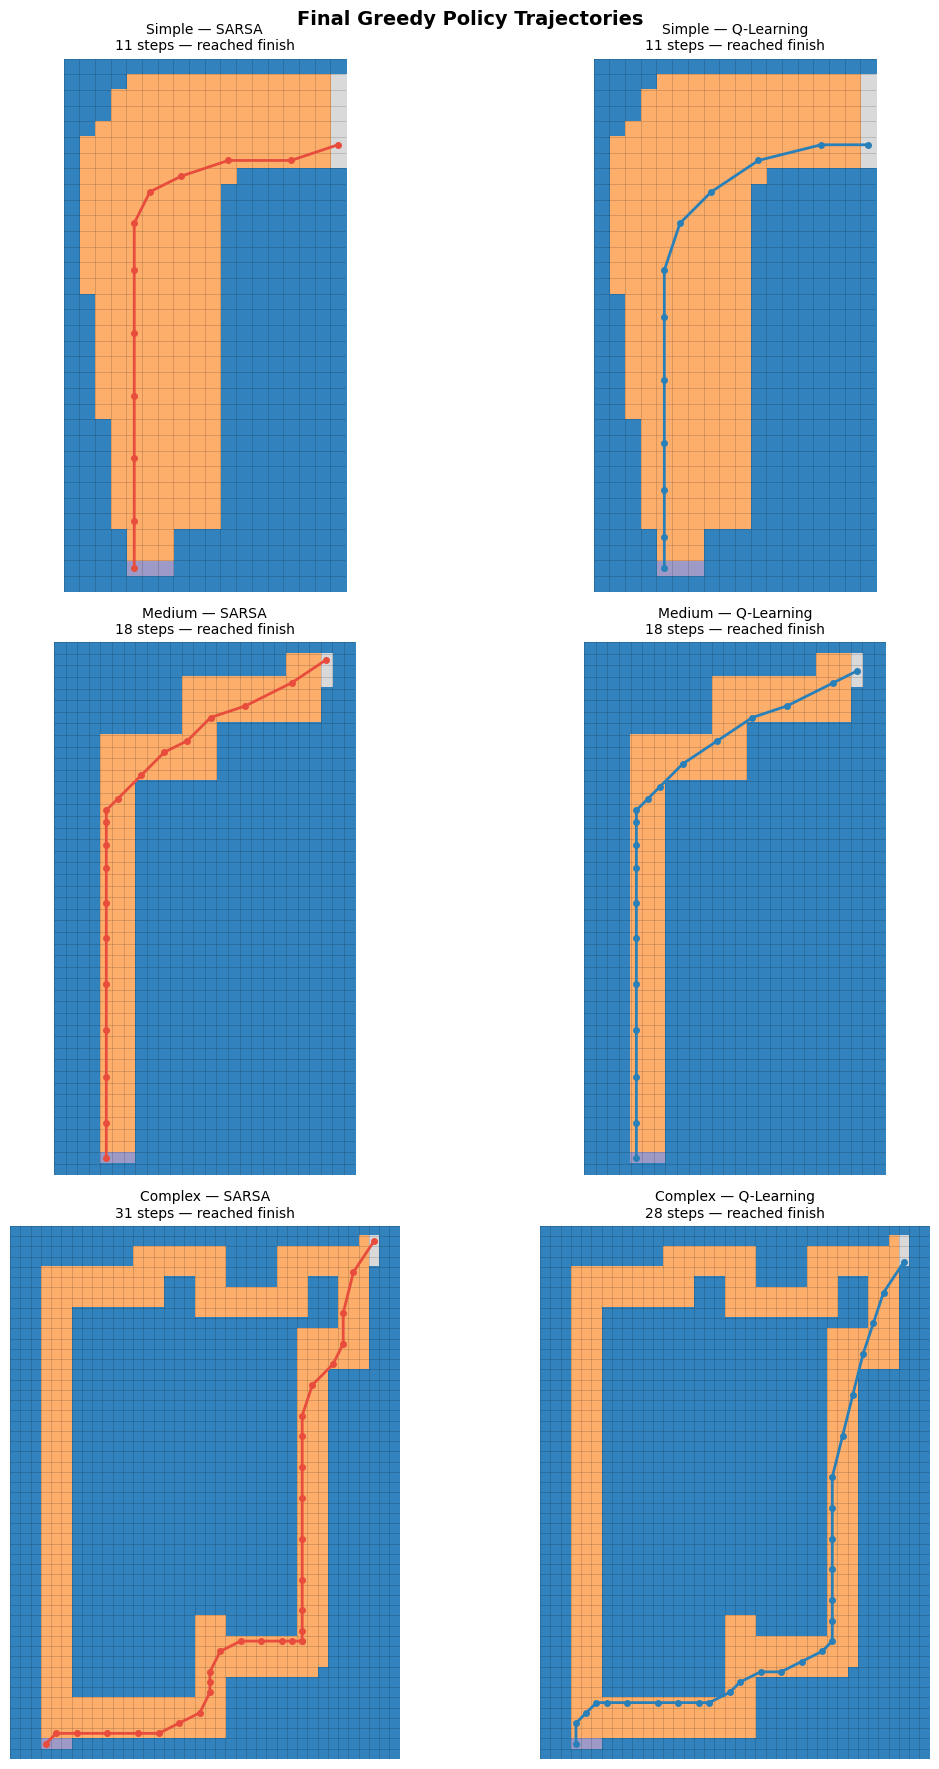

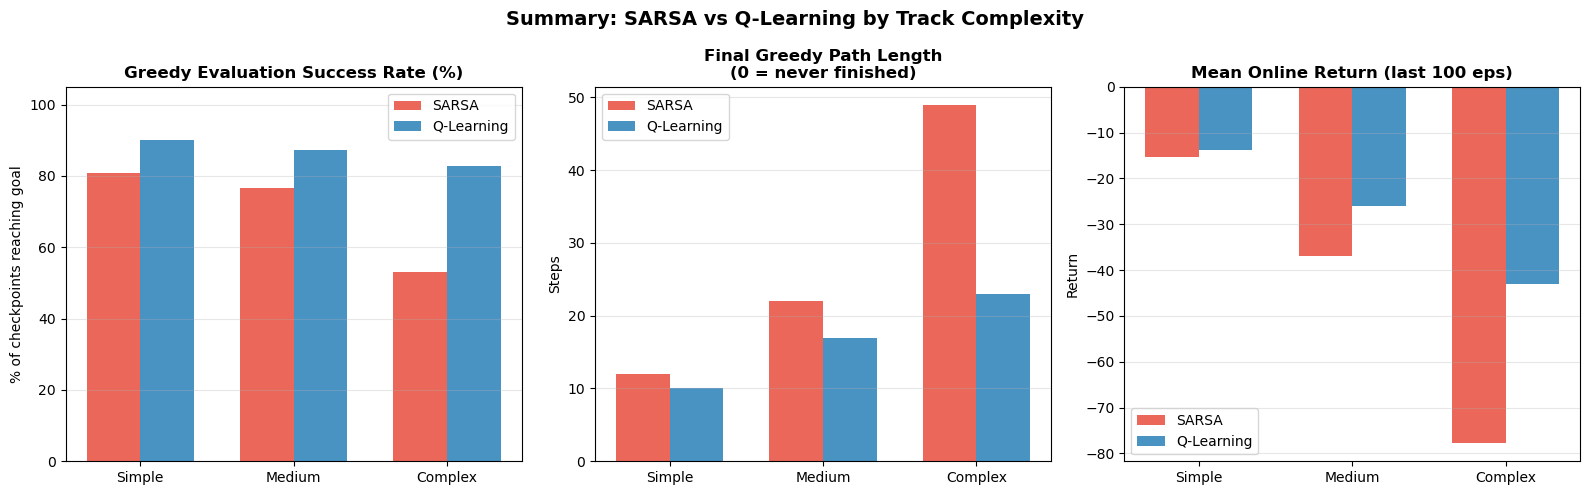


=== EXPERIMENT COMPLETE ===
Saved figures: td_online_return.png, td_learning_curves.png, td_trajectories.png, td_summary.png


In [14]:
MAX_EPISODES_S = 20000
MAX_EPISODES_Q = 20000

print("Starting TD experiment: SARSA vs Q-Learning")
print(f"Episodes: {MAX_EPISODES_S:,} {MAX_EPISODES_Q:,} | ε={EPSILON} | α={ALPHA} | γ={GAMMA} | seed={SEED}")

results_sarsa1 = run_all_difficulties_sarsa(max_episodes=MAX_EPISODES_S)
results_ql1    = run_all_difficulties_qlearning(max_episodes=MAX_EPISODES_Q)

print_evaluation_summary(results_sarsa1, results_ql1,
                          max_episodes_sarsa=MAX_EPISODES_S,
                          max_episodes_ql=MAX_EPISODES_Q)
plot_results(results_sarsa1, results_ql1)

print("\n=== EXPERIMENT COMPLETE ===")
print("Saved figures: td_online_return.png, td_learning_curves.png, "
      "td_trajectories.png, td_summary.png")

Starting TD experiment: SARSA vs Q-Learning
Episodes: 100,000 100,000 | ε=0.1 | α=0.5 | γ=1.0 | seed=0

  TRACK: SIMPLE  |  SARSA
  Grid: (34, 18) | Drivable cells: 289 | Starts: 3
  Training SARSA (100,000 episodes)...


SARSA: 100%|██████████| 100000/100000 [00:55<00:00, 1804.92it/s]


  first finish ep 100 | final path = 14 | late return = -14.4 | time = 55.4s

  TRACK: MEDIUM  |  SARSA
  Grid: (46, 26) | Drivable cells: 199 | Starts: 3
  Training SARSA (100,000 episodes)...


SARSA: 100%|██████████| 100000/100000 [01:54<00:00, 871.17it/s]


  first finish ep 550 | final path = 18 | late return = -27.3 | time = 114.8s

  TRACK: COMPLEX  |  SARSA
  Grid: (52, 38) | Drivable cells: 515 | Starts: 3
  Training SARSA (100,000 episodes)...


...

  first finish ep 350 | final path = 10 | late return = -12.5 | time = 56.1s

  TRACK: MEDIUM  |  Q-LEARNING
  Grid: (46, 26) | Drivable cells: 199 | Starts: 3
  Training Q-Learning (100,000 episodes)...


Q-Learning: 100%|██████████| 100000/100000 [01:36<00:00, 1039.88it/s]


  first finish ep 450 | final path = 16 | late return = -21.6 | time = 96.2s

  TRACK: COMPLEX  |  Q-LEARNING
  Grid: (52, 38) | Drivable cells: 515 | Starts: 3
  Training Q-Learning (100,000 episodes)...


Q-Learning: 100%|██████████| 100000/100000 [03:15<00:00, 512.20it/s]


  first finish ep 1000 | final path = 30 | late return = -43.6 | time = 195.3s

GREEDY EVALUATION STATUS SUMMARY
(SARSA: 2000 checkpoints | Q-Learning: 2000 checkpoints)
Track      Algo           finished   looped  timeout
------------------------------------------------------------
simple     SARSA              1909       91        0     95.5%
simple     Q-Learning         1955       45        0     97.8%
medium     SARSA              1830      170        0     91.5%
medium     Q-Learning         1952       48        0     97.6%
complex    SARSA              1555      445        0     77.8%
complex    Q-Learning         1928       72        0     96.4%


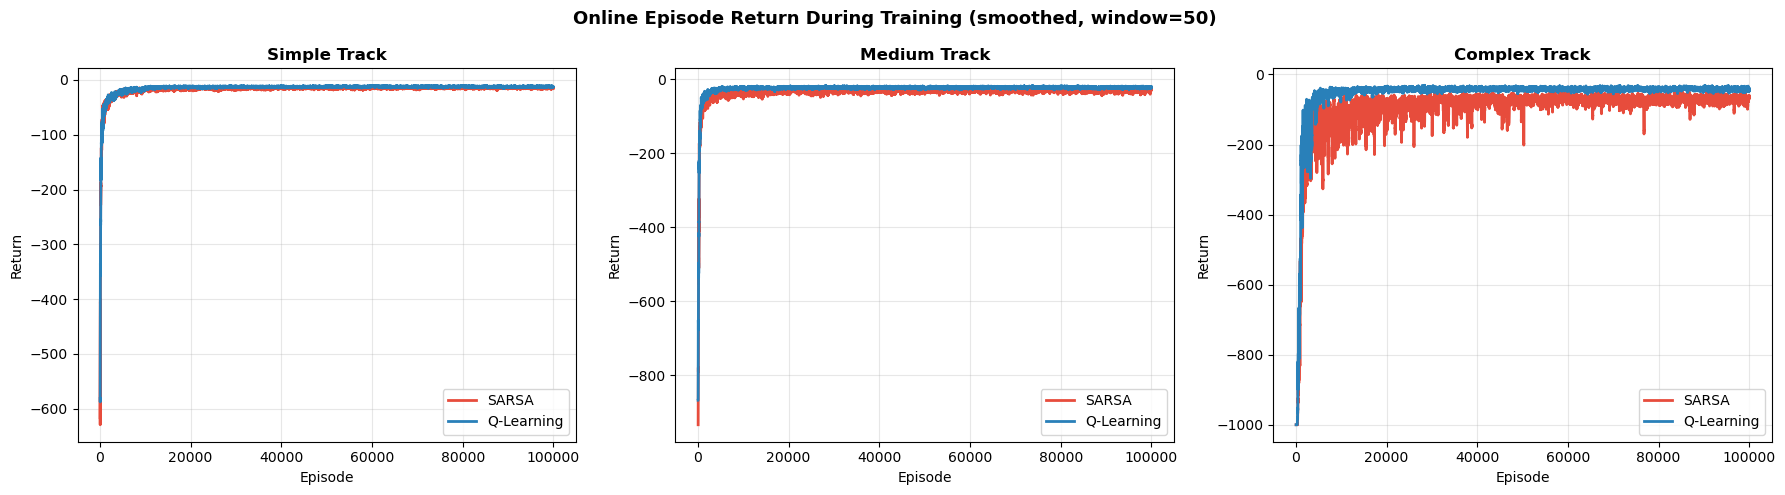

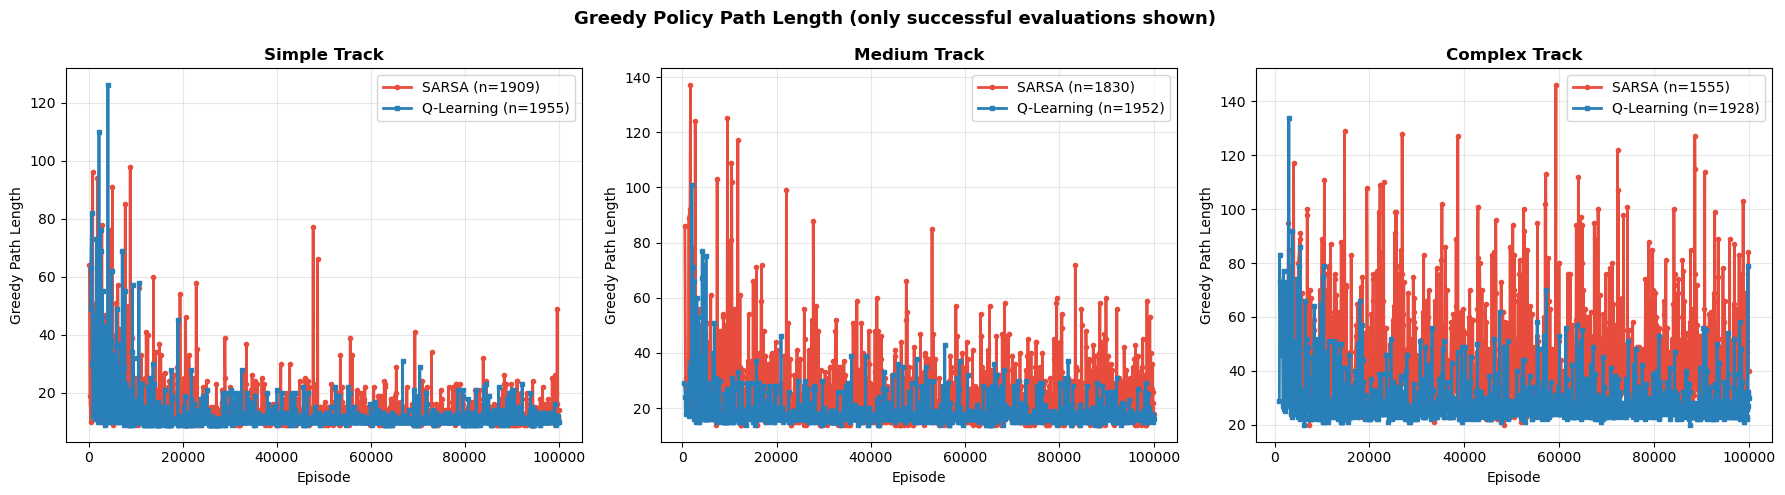

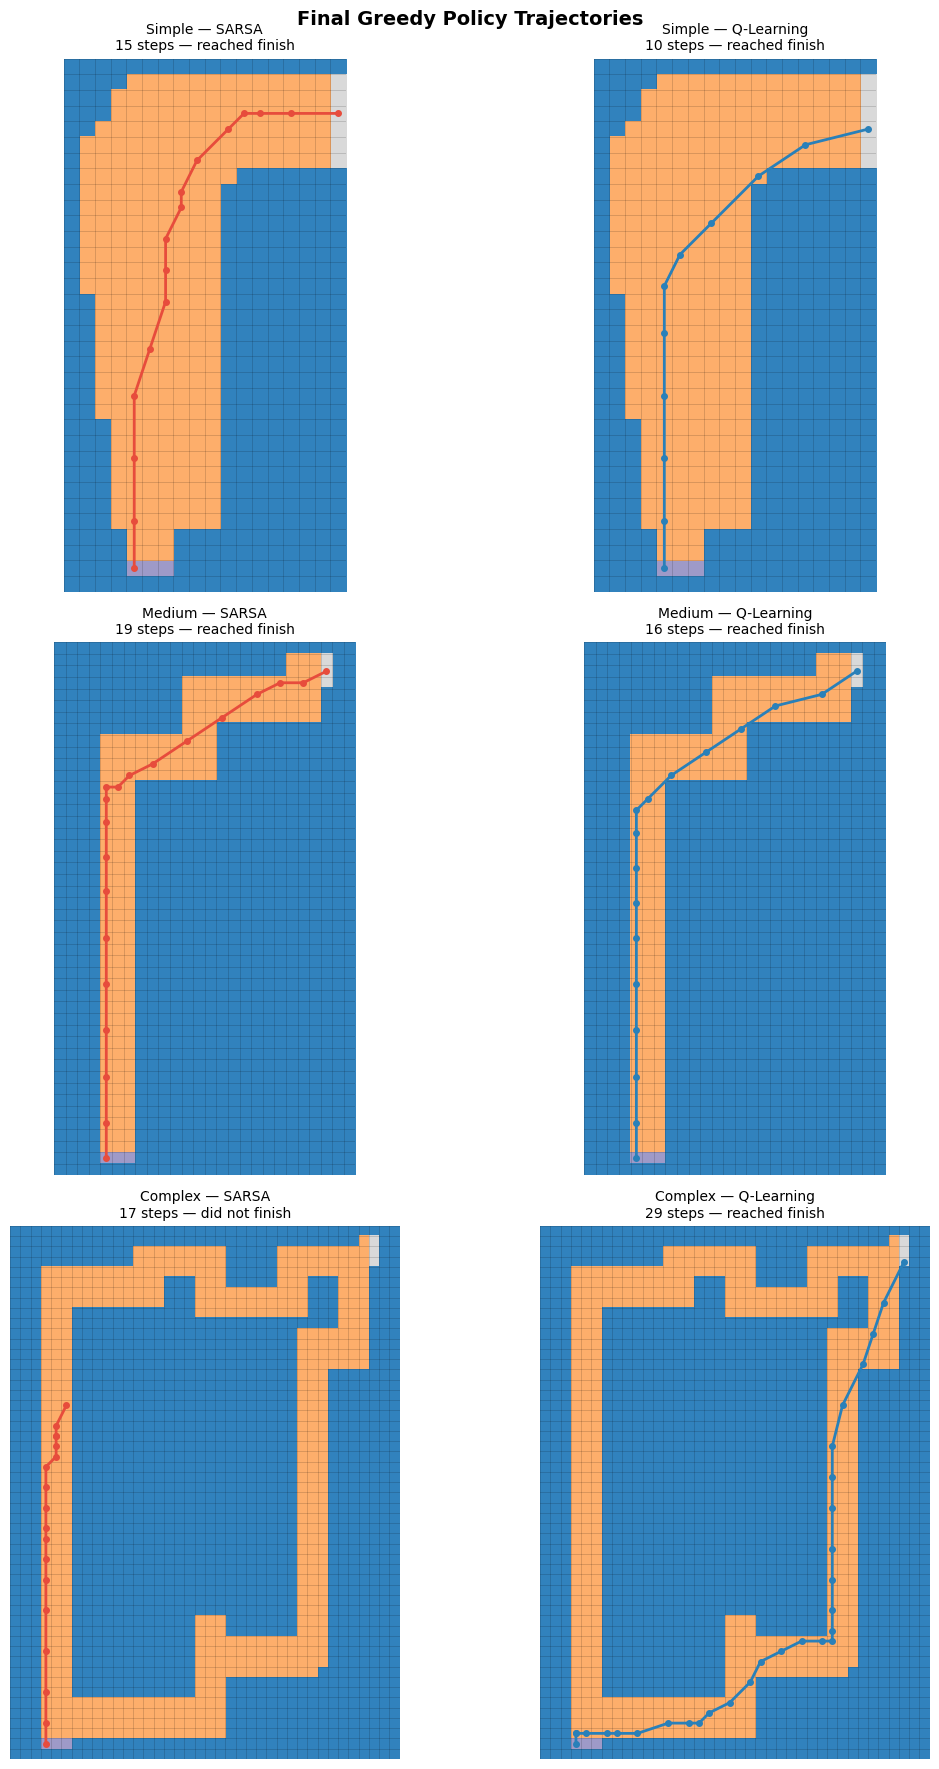

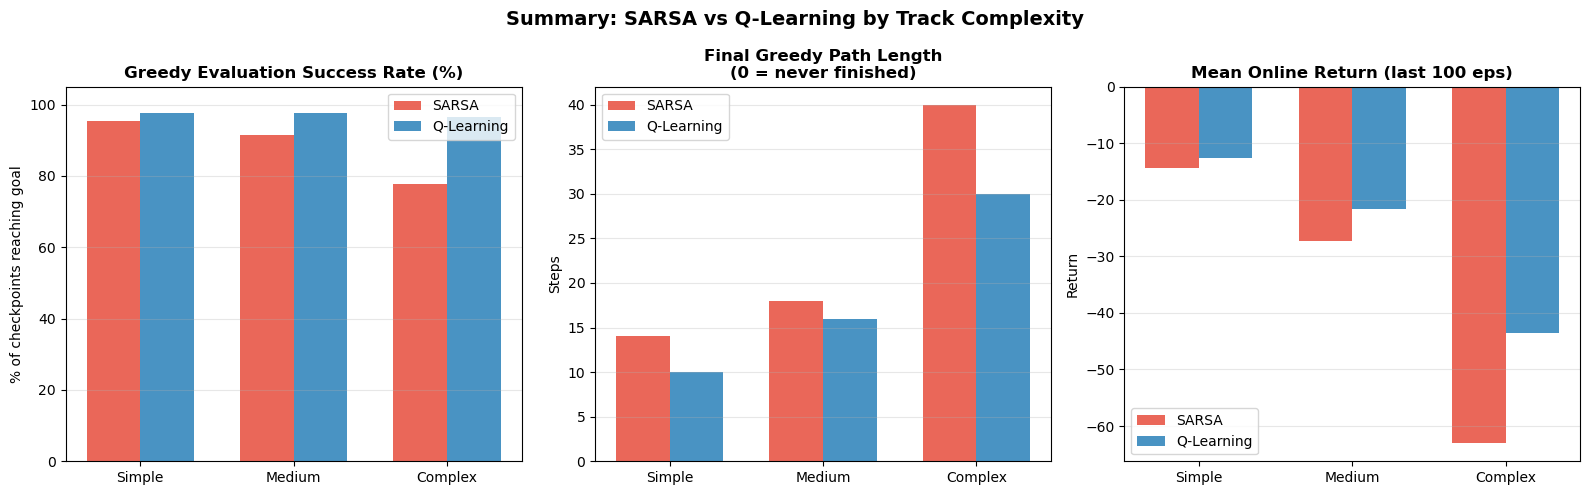


=== EXPERIMENT COMPLETE ===
Saved figures: td_online_return.png, td_learning_curves.png, td_trajectories.png, td_summary.png


In [15]:
MAX_EPISODES_S = 100000
MAX_EPISODES_Q = 100000

print("Starting TD experiment: SARSA vs Q-Learning")
print(f"Episodes: {MAX_EPISODES_S:,} {MAX_EPISODES_Q:,} | ε={EPSILON} | α={ALPHA} | γ={GAMMA} | seed={SEED}")

results_sarsa2 = run_all_difficulties_sarsa(max_episodes=MAX_EPISODES_S)
results_ql2   = run_all_difficulties_qlearning(max_episodes=MAX_EPISODES_Q)

print_evaluation_summary(results_sarsa2, results_ql2,
                          max_episodes_sarsa=MAX_EPISODES_S,
                          max_episodes_ql=MAX_EPISODES_Q)
plot_results(results_sarsa2, results_ql2)

print("\n=== EXPERIMENT COMPLETE ===")
print("Saved figures: td_online_return.png, td_learning_curves.png, "
      "td_trajectories.png, td_summary.png")

# table

In [38]:
MAX_EPISODES_S = 40000
MAX_EPISODES_Q = 40000
print(f"max episodes: SARSA {MAX_EPISODES_S} Q-learning {MAX_EPISODES_S}")
print_evaluation_summary(results_sarsa, results_ql,
                          max_episodes_sarsa=MAX_EPISODES_S,
                          max_episodes_ql=MAX_EPISODES_Q)

max episodes: SARSA 40000 Q-learning 40000

GREEDY EVALUATION STATUS SUMMARY
(SARSA: 800 checkpoints | Q-Learning: 800 checkpoints)
Track      Algo           finished   looped  timeout     %fin  avg_steps
--------------------------------------------------------------------------------
simple     SARSA               721       79        0     90.1%       16.9
simple     Q-Learning          752       48        0     94.0%       14.3
medium     SARSA               687      113        0     85.9%       25.2
medium     Q-Learning          753       47        0     94.1%       18.9
complex    SARSA               522      278        0     65.2%       44.2
complex    Q-Learning          714       86        0     89.2%       28.6


In [39]:
MAX_EPISODES_S = 20000
MAX_EPISODES_Q = 20000
print(f"max episodes: SARSA {MAX_EPISODES_S} Q-learning {MAX_EPISODES_S}")
print_evaluation_summary(results_sarsa1, results_ql1,
                          max_episodes_sarsa=MAX_EPISODES_S,
                          max_episodes_ql=MAX_EPISODES_Q)

max episodes: SARSA 20000 Q-learning 20000

GREEDY EVALUATION STATUS SUMMARY
(SARSA: 400 checkpoints | Q-Learning: 400 checkpoints)
Track      Algo           finished   looped  timeout     %fin  avg_steps
--------------------------------------------------------------------------------
simple     SARSA               323       77        0     80.8%       19.5
simple     Q-Learning          360       40        0     90.0%       17.3
medium     SARSA               306       94        0     76.5%       27.1
medium     Q-Learning          349       51        0     87.2%       20.2
complex    SARSA               212      188        0     53.0%       46.4
complex    Q-Learning          331       69        0     82.8%       29.8


In [40]:
MAX_EPISODES_S = 100000
MAX_EPISODES_Q = 100000
print(f"max episodes: SARSA {MAX_EPISODES_S} Q-learning {MAX_EPISODES_S}")
print_evaluation_summary(results_sarsa2, results_ql2,
                          max_episodes_sarsa=MAX_EPISODES_S,
                          max_episodes_ql=MAX_EPISODES_Q)



max episodes: SARSA 100000 Q-learning 100000

GREEDY EVALUATION STATUS SUMMARY
(SARSA: 2000 checkpoints | Q-Learning: 2000 checkpoints)
Track      Algo           finished   looped  timeout     %fin  avg_steps
--------------------------------------------------------------------------------
simple     SARSA              1909       91        0     95.5%       14.2
simple     Q-Learning         1955       45        0     97.8%       12.1
medium     SARSA              1830      170        0     91.5%       24.1
medium     Q-Learning         1952       48        0     97.6%       18.0
complex    SARSA              1555      445        0     77.8%       42.8
complex    Q-Learning         1928       72        0     96.4%       27.8


# policy

## code (results see `.txt` files)

In [19]:
def print_policy(Q, track, actions, name=""):
    """Print the greedy action at every drivable cell"""
    action_symbols = {
        (-1,-1):"↙", (-1, 0):"←", (-1, 1):"↖",
        ( 0,-1):"↓", ( 0, 0):"●", ( 0, 1):"↑",
        ( 1,-1):"↘", ( 1, 0):"→", ( 1, 1):"↗",
    }
    rows, cols = track.shape
    print(f"\n=== Policy: {name} ===")
    for r in range(rows):
        row_str = ""
        for c in range(cols):
            if track[r, c] == 0:
                row_str += "  "       # wall
            elif track[r, c] == 2:
                row_str += "S "       # start
            elif track[r, c] == 3:
                row_str += "F "       # finish
            else:
                idx = racetrack.greedy_action_index(Q, (r, c, 2, 0))
                row_str += action_symbols[actions[idx]] + " "
        print(row_str)

In [20]:
for name in ["simple", "medium", "complex"]:
    print_policy(results_sarsa2[name]["Q"],
                 results_sarsa2[name]["track"],
                 results_sarsa2[name]["actions"],
                 f"{name} — SARSA")
    print_policy(results_ql2[name]["Q"],
                 results_ql2[name]["track"],
                 results_ql2[name]["actions"],
                 f"{name} — Q-Learning")


=== Policy: simple — SARSA ===
                                    
        ↙ ● ← ← ↖ ↘ ↘ ↓ ↑ ↘ ↙ ← ← F 
      ↑ ↙ ↙ ↘ ↓ ↘ ↙ ↙ ↘ ↗ ↓ ↘ ● ↙ F 
      ↘ ↓ ↘ ↓ ↘ ↘ ↓ ↙ ↙ → ↘ ↖ ↘ ↙ F 
    ↑ ↑ ● ↘ ↓ ↙ ↘ ↙ ↘ ● ↗ ↙ ↘ ● ↖ F 
  ↑ ↑ ↙ ↙ ↓ ↓ ↓ ↘ ↘ ↙ ↑ ↙ → ● ↑ ↙ F 
  ↖ ● ● ← ↘ ↘ ↓ ↓ ● ↑ ↓ ↙ ↑ ● ← ↓ F 
  ↑ ↖ → → ↙ ↓ ↘ ↓ ↘ ↓               
  ↙ ↙ ↗ ↙ ↙ ↙ → ↓ ↙                 
  ← ↑ ↙ ↓ ↓ ← → → ●                 
  ← ← ● ↓ ↘ ↙ ← ↙ ←                 
  ↙ ↖ ↘ ↘ ↓ → → → ●                 
  → ↗ ↙ ↙ ← ↗ ← ● ↑                 
  ● ↖ ↘ ↗ ↙ ● ↙ → ●                 
  ↓ ↗ ← → ← ↑ ↙ ● ←                 
    → → ↙ ↖ ← ↑ ↖ ↖                 
    ↓ ← → ↗ → ● ← ↑                 
    ← ↙ ↗ ↑ ↑ ● ● ←                 
    ↘ ← ↗ ↑ ↖ ↖ ● ↑                 
    ↑ ↙ ↓ ↖ ← → ← ↖                 
    ↖ ↙ ↓ ↓ ↑ ● ↑ ●                 
    ↙ ↗ ← ↗ ↑ ↖ ↖ ↑                 
    ← ↘ ↖ ↖ ← ← ↓ ●                 
      ← ● ↗ ↑ ↗ ● ↑                 
      ↖ → ↑ ↓ ↑ ↓ ←                 
      ● ← ↑ ↑ ↖ ↑ →                 
      

In [23]:
import sys

def print_policy_to_file(Q, track, actions, name, filepath):
    action_symbols = {
        (-1,-1):"↙", (-1, 0):"←", (-1, 1):"↖",
        ( 0,-1):"↓", ( 0, 0):"●", ( 0, 1):"↑",
        ( 1,-1):"↘", ( 1, 0):"→", ( 1, 1):"↗",
    }
    rows, cols = track.shape
    with open(filepath, "a", encoding="utf-8") as f:
        f.write(f"\n=== Policy: {name} ===\n")
        for r in range(rows):
            row_str = ""
            for c in range(cols):
                if track[r, c] == 0:
                    row_str += "  "
                elif track[r, c] == 2:
                    row_str += "S "
                elif track[r, c] == 3:
                    row_str += "F "
                else:
                    idx = racetrack.greedy_action_index(Q, (r, c, 2, 0))
                    row_str += action_symbols[actions[idx]] + " "
            f.write(row_str + "\n")


for name in ["simple", "medium", "complex"]:
    print_policy_to_file(results_sarsa2[name]["Q"], results_sarsa2[name]["track"],
                         results_sarsa2[name]["actions"], f"{name} — SARSA", "policy_100000.txt")
    print_policy_to_file(results_ql2[name]["Q"],    results_ql2[name]["track"],
                         results_ql2[name]["actions"],    f"{name} — Q-Learning", "policy_100000.txt")

# trajectories

In [33]:
def plot_success_failure(model_results, model_name, color="#333333",
                         max_steps=300, failure_epsilon=0.3):
    """
    For each track, plots one successful (greedy) and one failed (epsilon-noisy) trajectory.

    Args:
        model_results     : dict — e.g. results_sarsa or results_ql
        model_name        : str  — e.g. "SARSA" or "Q-Learning"
        color             : str  — trajectory line colour
        max_steps         : int  — step cap per episode
        failure_epsilon   : float — epsilon used when hunting for a failure;
                                    increase if failures are hard to find
    """
    track_names = list(model_results.keys())
    n = len(track_names)

    fig, axes = plt.subplots(n, 2, figsize=(10, 5 * n))
    fig.suptitle(f"Success vs Failure — {model_name}", fontsize=14, fontweight="bold")

    for i, name in enumerate(track_names):
        d       = model_results[name]
        track   = d["track"]
        starts  = d["starts"]
        actions = d["actions"]
        Q       = d["Q"]

        for col, want_success in enumerate([True, False]):
            ax = axes[i][col] if n > 1 else axes[col]

            # success → pure greedy (epsilon=0); failure → noisy policy
            eps        = 0.0 if want_success else failure_epsilon
            found_path = None
            found_done = False
            found_steps = 0

            for attempt in range(200):   # try up to 200 stochastic episodes
                start_pos = starts[attempt % len(starts)]
                env_state = racetrack.reset_env(None, start_pos=start_pos)
                path_y, path_x = [env_state[0]], [env_state[1]]
                done, steps = False, 0

                while not done and steps < max_steps:
                    agent_state = racetrack.get_agent_state(env_state)
                    # epsilon-greedy: random action with prob eps
                    if eps > 0 and random.random() < eps:
                        a_idx = random.randrange(len(actions))
                    else:
                        a_idx = racetrack.greedy_action_index(Q, agent_state)
                    best_a = actions[a_idx]
                    next_state, _, done = racetrack.step_env(track, env_state, best_a)
                    if abs(next_state[0] - env_state[0]) > 5 or abs(next_state[1] - env_state[1]) > 5:
                        break
                    env_state = next_state
                    path_y.append(env_state[0])
                    path_x.append(env_state[1])
                    steps += 1

                if done == want_success:
                    found_path  = (path_x, path_y)
                    found_done  = done
                    found_steps = steps
                    break

            # --- plot ---
            ax.imshow(track, cmap="tab20c")
            label = "✓ Success" if want_success else "✗ Failure"
            if found_path:
                ax.plot(found_path[0], found_path[1],
                        marker="o", color=color, markersize=3, linewidth=1.8)
                status = "finished" if found_done else "did not finish"
                title  = f"{name.capitalize()} | {label}\n{found_steps} steps — {status}"
            else:
                title = f"{name.capitalize()} | {label}\nnot found"

            ax.set_title(title, fontsize=9)
            ax.set_xticks(np.arange(-.5, track.shape[1], 1), minor=True)
            ax.set_yticks(np.arange(-.5, track.shape[0], 1), minor=True)
            ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4, alpha=0.2)
            ax.tick_params(which="both", bottom=False, left=False,
                           labelbottom=False, labelleft=False)
            for spine in ax.spines.values():
                spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(f"trajectories_{model_name.lower().replace(' ', '_')}_sf.png",
                dpi=120, bbox_inches="tight")
    plt.show()


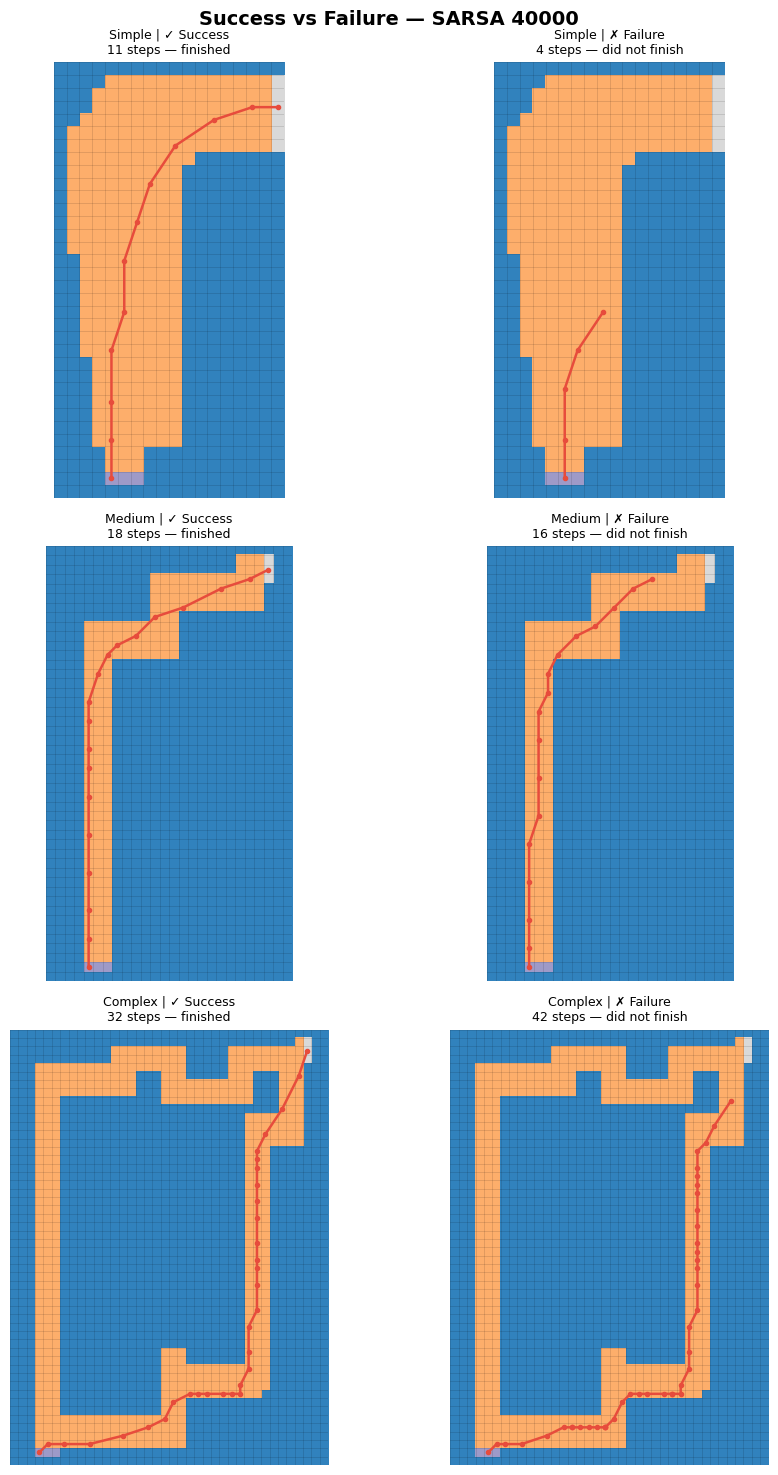

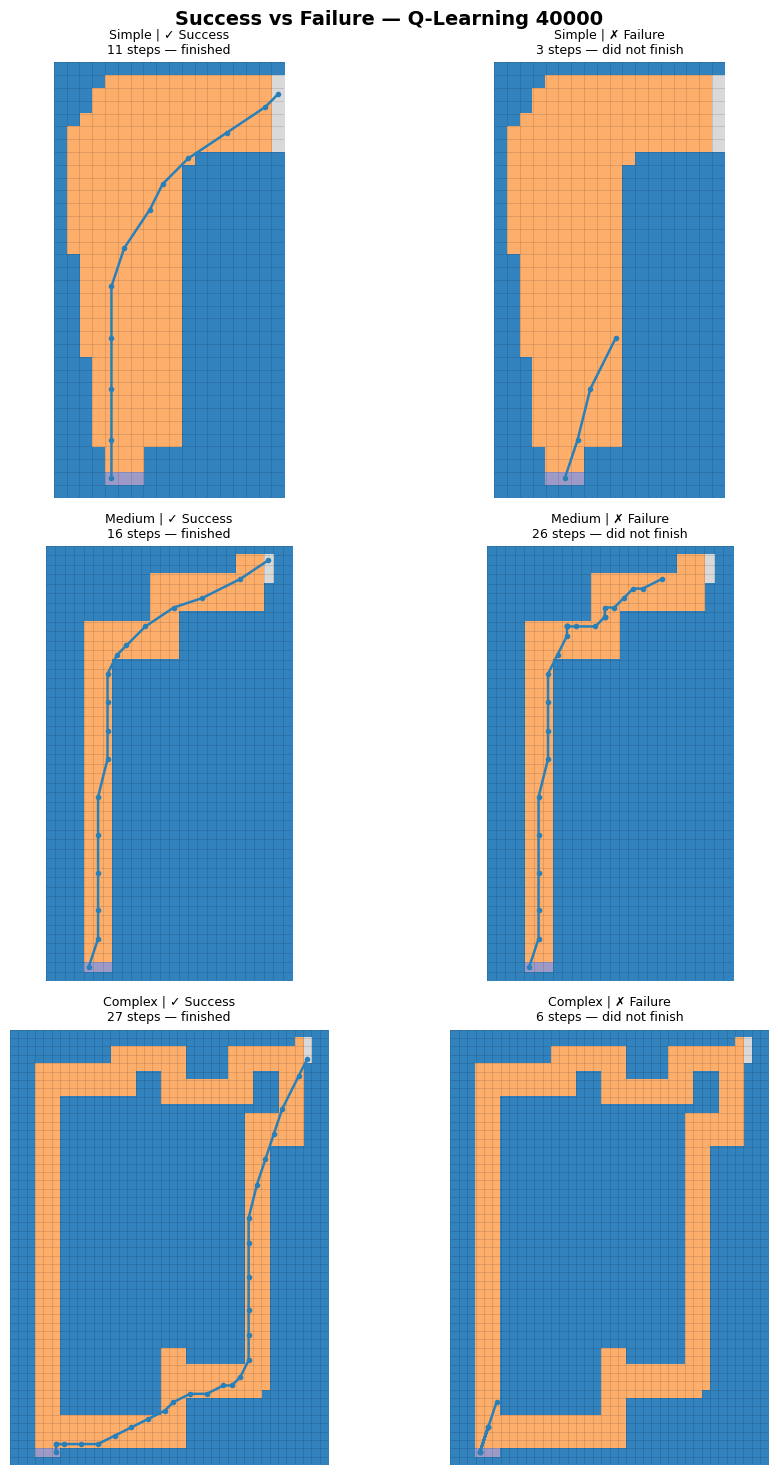

In [34]:
plot_success_failure(results_sarsa, "SARSA 40000",      color="#E74C3C")
plot_success_failure(results_ql,    "Q-Learning 40000", color="#2980B9")

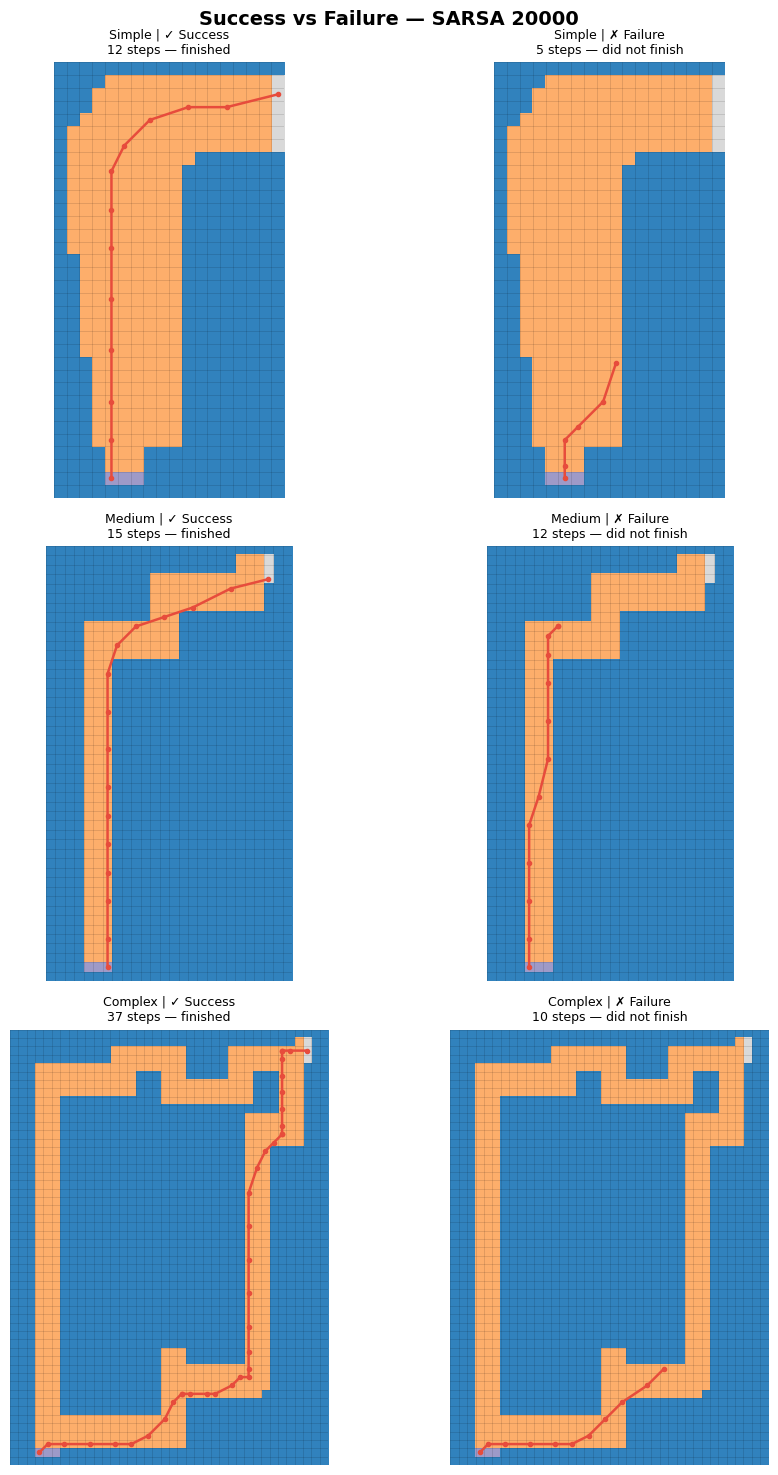

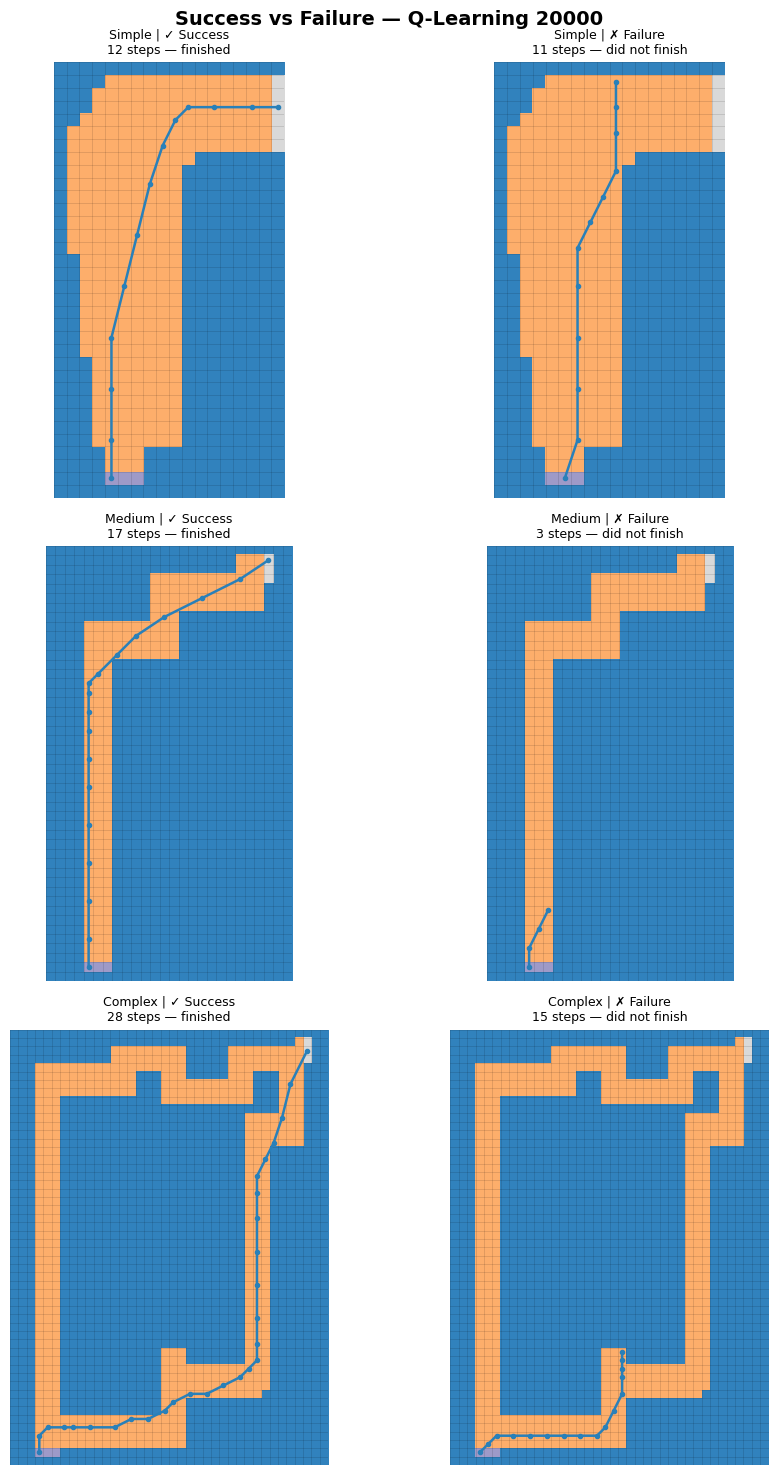

In [35]:
plot_success_failure(results_sarsa1, "SARSA 20000",      color="#E74C3C")
plot_success_failure(results_ql1,    "Q-Learning 20000", color="#2980B9")

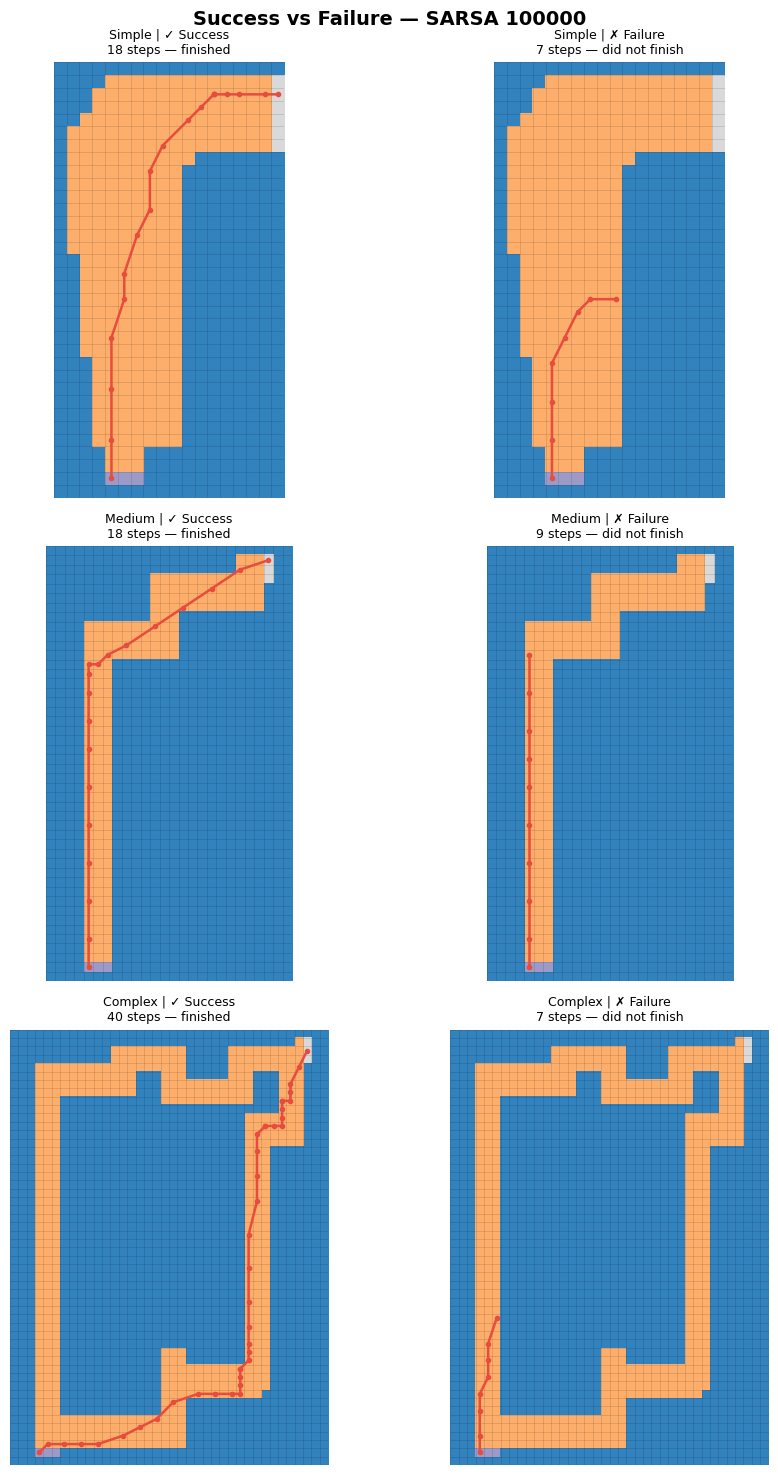

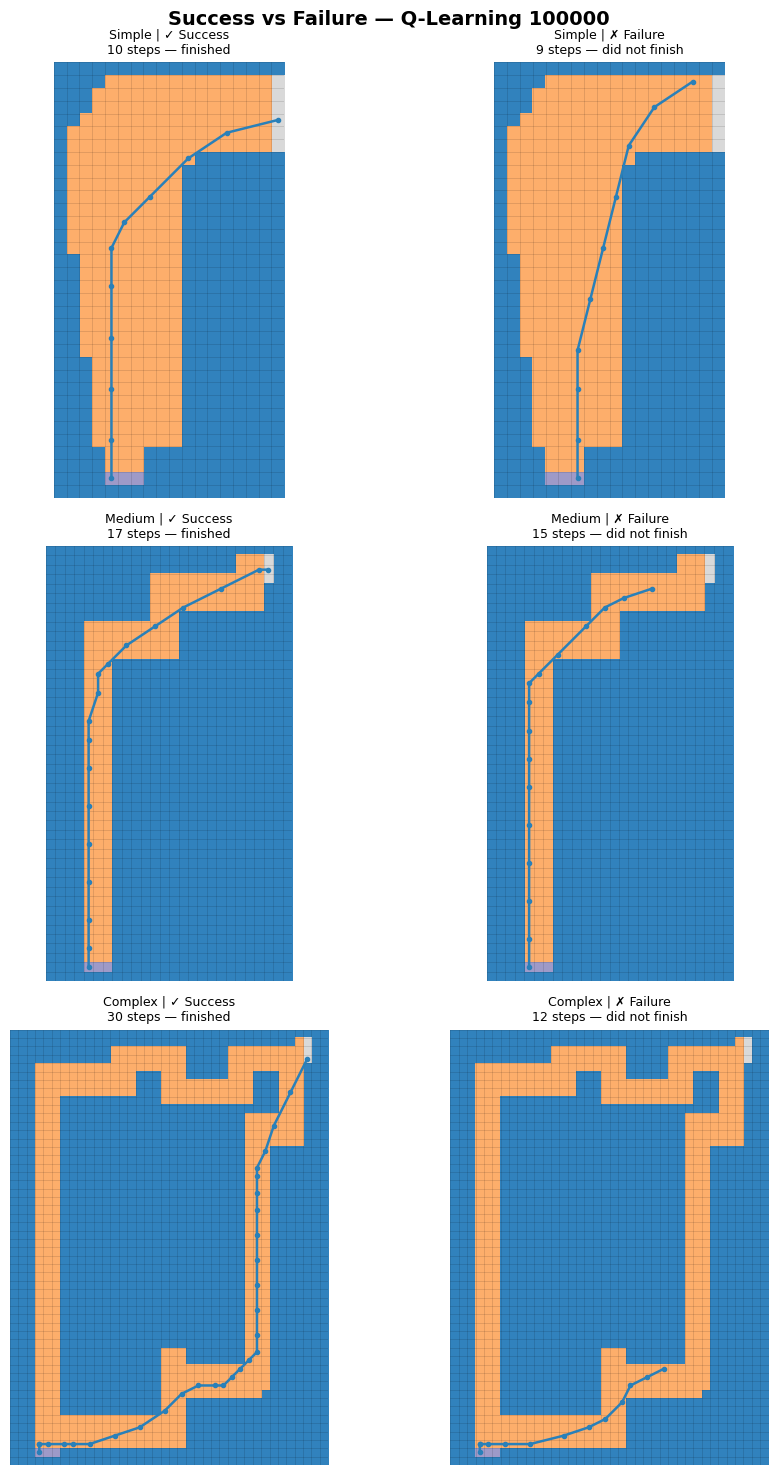

In [36]:
plot_success_failure(results_sarsa2, "SARSA 100000",      color="#E74C3C")
plot_success_failure(results_ql2,    "Q-Learning 100000", color="#2980B9")